<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/rnn/001-simple-rnn-from-scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN - Simple RNN from Scratch

In this notebook, we build a simple Recurrent Neural Network (RNN) from scratch using PyTorch, **without using high-level modules like `nn.RNN`**.  
We'll walk step by step through how an RNN operates internally by manually defining weight matrices, biases, and performing forward passes through the sequence.

We aim to teach our RNN to predict the next number in a simple linear sequence.  
For example, given a sequence:
```
1, 2, 3, 4, ..., n
```
The model should learn to predict:
```
2, 3, 4, 5, ..., n+1
```


Let's generate a sequence of numbers:

In [71]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

seq_length = 20

# Generate toy data: fixed starting point for clarity
def generate_sequence(start=1.0):
    _start = torch.tensor([start])
    seq = _start + torch.arange(seq_length).float()
    return seq.unsqueeze(-1)  # shape: (seq_length, 1)

seq = generate_sequence()
seq.shape, seq

(torch.Size([20, 1]),
 tensor([[ 1.],
         [ 2.],
         [ 3.],
         [ 4.],
         [ 5.],
         [ 6.],
         [ 7.],
         [ 8.],
         [ 9.],
         [10.],
         [11.],
         [12.],
         [13.],
         [14.],
         [15.],
         [16.],
         [17.],
         [18.],
         [19.],
         [20.]]))

And let's generate the corrresponding sequence (the same sequence shifted by one position):

In [38]:
# Target is next number in sequence
def get_target(seq):
    return torch.roll(seq, shifts=-1, dims=0)

target = get_target(seq)
target.shape, target

(torch.Size([20, 1]),
 tensor([[ 2.],
         [ 3.],
         [ 4.],
         [ 5.],
         [ 6.],
         [ 7.],
         [ 8.],
         [ 9.],
         [10.],
         [11.],
         [12.],
         [13.],
         [14.],
         [15.],
         [16.],
         [17.],
         [18.],
         [19.],
         [20.],
         [ 1.]]))

Let's defined the model parameters:

In [39]:
input_size = 1    # size of each input element (scalar sequence)
hidden_size = 16  # size of hidden state

# Manual parameters as nn.Parameter (leaf tensors!)
Wxh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.1)
Whh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)
Why = nn.Parameter(torch.randn(hidden_size, input_size) * 0.1)
bh = nn.Parameter(torch.zeros(1, hidden_size))
by = nn.Parameter(torch.zeros(1, input_size))

Let's pluck the first value in the sequence to feed into the RNN:

In [53]:
x_t = seq[0].unsqueeze(0)  # shape: (1, input_size)
x_t.shape, x_t

(torch.Size([1, 1]), tensor([[1.]]))

Let's initialize the hidden state:

In [41]:
batch_size = 1    # single sequence
h = torch.zeros(batch_size, hidden_size)
h.shape, h

(torch.Size([1, 16]),
 tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]))

And now let's simulate the forward pass of a single input (one item from the sequence). Basically we want to matmul the input with the input weight matrix, then sum the hidden state matmuled with the hidden state weight matrix, then add a hidden state bias, then run a nonlinear activation over the whole thing):

In [42]:
h = torch.tanh(x_t @ Wxh + h @ Whh + bh)
h.shape, h

(torch.Size([1, 16]),
 tensor([[ 0.1755,  0.0006,  0.1261, -0.0204,  0.0892, -0.0003,  0.0129, -0.0206,
           0.0926, -0.0569,  0.0581, -0.0543, -0.0635, -0.0132, -0.0183, -0.1105]],
        grad_fn=<TanhBackward0>))

Now that we have the new hidden state, we can calculate the output by matmuling it with the weight matrix for the output and summing the output bias.

In [43]:
y_t = h @ Why + by
y_t.shape, y_t

(torch.Size([1, 1]), tensor([[0.0522]], grad_fn=<AddBackward0>))

Processing the whole sequence is similar, with the nuance that the hidden state calculated from the previous input is going to be part of the calculation for the next input in the sequence, this allows information from the previous input to feed into the next allowing preceding context to inform how the next input will be processed:

In [44]:
outputs = []
for t in range(seq_length):
    x_t = seq[t].unsqueeze(0)  # shape: (1, input_size)
    h = torch.tanh(x_t @ Wxh + h @ Whh + bh)
    y_t = h @ Why + by
    outputs.append(y_t)
outputs

[tensor([[0.0410]], grad_fn=<AddBackward0>),
 tensor([[0.0900]], grad_fn=<AddBackward0>),
 tensor([[0.1264]], grad_fn=<AddBackward0>),
 tensor([[0.1573]], grad_fn=<AddBackward0>),
 tensor([[0.1850]], grad_fn=<AddBackward0>),
 tensor([[0.2080]], grad_fn=<AddBackward0>),
 tensor([[0.2277]], grad_fn=<AddBackward0>),
 tensor([[0.2443]], grad_fn=<AddBackward0>),
 tensor([[0.2582]], grad_fn=<AddBackward0>),
 tensor([[0.2699]], grad_fn=<AddBackward0>),
 tensor([[0.2796]], grad_fn=<AddBackward0>),
 tensor([[0.2879]], grad_fn=<AddBackward0>),
 tensor([[0.2949]], grad_fn=<AddBackward0>),
 tensor([[0.3009]], grad_fn=<AddBackward0>),
 tensor([[0.3061]], grad_fn=<AddBackward0>),
 tensor([[0.3107]], grad_fn=<AddBackward0>),
 tensor([[0.3147]], grad_fn=<AddBackward0>),
 tensor([[0.3183]], grad_fn=<AddBackward0>),
 tensor([[0.3215]], grad_fn=<AddBackward0>),
 tensor([[0.3244]], grad_fn=<AddBackward0>)]

We have collected all our outputs, but we need to have them in a shape matching the sequence target, which is a tensor `(20, 1)`, to do so, we need only to concaneate the list:

In [45]:
outputs = torch.cat(outputs, dim=0)
outputs.shape, outputs

(torch.Size([20, 1]),
 tensor([[0.0410],
         [0.0900],
         [0.1264],
         [0.1573],
         [0.1850],
         [0.2080],
         [0.2277],
         [0.2443],
         [0.2582],
         [0.2699],
         [0.2796],
         [0.2879],
         [0.2949],
         [0.3009],
         [0.3061],
         [0.3107],
         [0.3147],
         [0.3183],
         [0.3215],
         [0.3244]], grad_fn=<CatBackward0>))

We can now compare the predicted sequence to the target sequence and calculate the loss:

In [46]:
loss_fn = nn.MSELoss()
loss = loss_fn(outputs, target)
loss

tensor(137.7488, grad_fn=<MseLossBackward0>)

We now have everything we need to run a training loop:

In [60]:
# Hyperparameters
num_epochs = 100
learning_rate = 0.01

loss_fn = nn.MSELoss()

# Optimizer
params = [Wxh, Whh, Why, bh, by]
optimizer = torch.optim.Adam(params, lr=learning_rate)

loss_history = []
for epoch in range(num_epochs):
    seq = generate_sequence()
    target = get_target(seq)

    # Initialize hidden state
    h = torch.zeros(batch_size, hidden_size)

    outputs = []
    hidden_states = []  # For visualization

    for t in range(seq_length):
        x_t = seq[t].unsqueeze(0)  # shape: (1, input_size)
        h = torch.tanh(x_t @ Wxh + h @ Whh + bh)
        y_t = h @ Why + by

        outputs.append(y_t)
        hidden_states.append(h.detach().numpy())  # store for later

    outputs = torch.cat(outputs, dim=0)

    loss = loss_fn(outputs, target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')


Epoch [10/100], Loss: 12.7292
Epoch [20/100], Loss: 12.5509
Epoch [30/100], Loss: 12.5549
Epoch [40/100], Loss: 12.5508
Epoch [50/100], Loss: 12.5442
Epoch [60/100], Loss: 12.5427
Epoch [70/100], Loss: 12.5425
Epoch [80/100], Loss: 12.5424
Epoch [90/100], Loss: 12.5424
Epoch [100/100], Loss: 12.5424


Now that the network is trained, let's check its predictions again:

In [73]:
outputs=[]
with torch.no_grad():
    seq = generate_sequence()
    target = get_target(seq)
    outputs = []
    h = torch.zeros(batch_size, hidden_size)
    for t in range(seq_length):
        x_t = seq[t].unsqueeze(0)  # shape: (1, input_size)
        h = torch.tanh(x_t @ Wxh + h @ Whh + bh)
        y_t = h @ Why + by
        outputs.append(y_t)
torch.round(torch.cat(outputs)), target

(tensor([[ 2.],
         [ 3.],
         [ 4.],
         [ 5.],
         [ 6.],
         [ 7.],
         [ 8.],
         [ 9.],
         [10.],
         [11.],
         [12.],
         [13.],
         [14.],
         [15.],
         [15.],
         [15.],
         [15.],
         [15.],
         [15.],
         [15.]]),
 tensor([[ 2.],
         [ 3.],
         [ 4.],
         [ 5.],
         [ 6.],
         [ 7.],
         [ 8.],
         [ 9.],
         [10.],
         [11.],
         [12.],
         [13.],
         [14.],
         [15.],
         [16.],
         [17.],
         [18.],
         [19.],
         [20.],
         [ 1.]]))

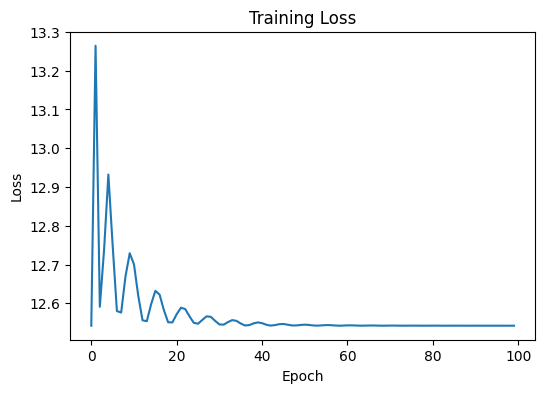

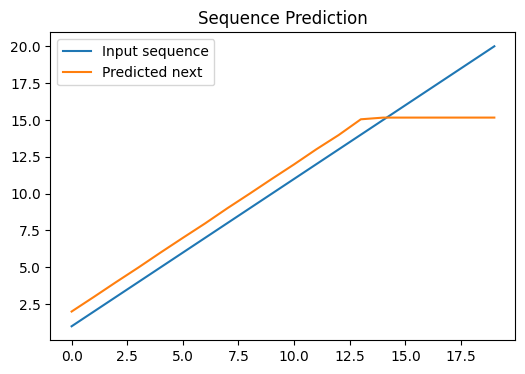

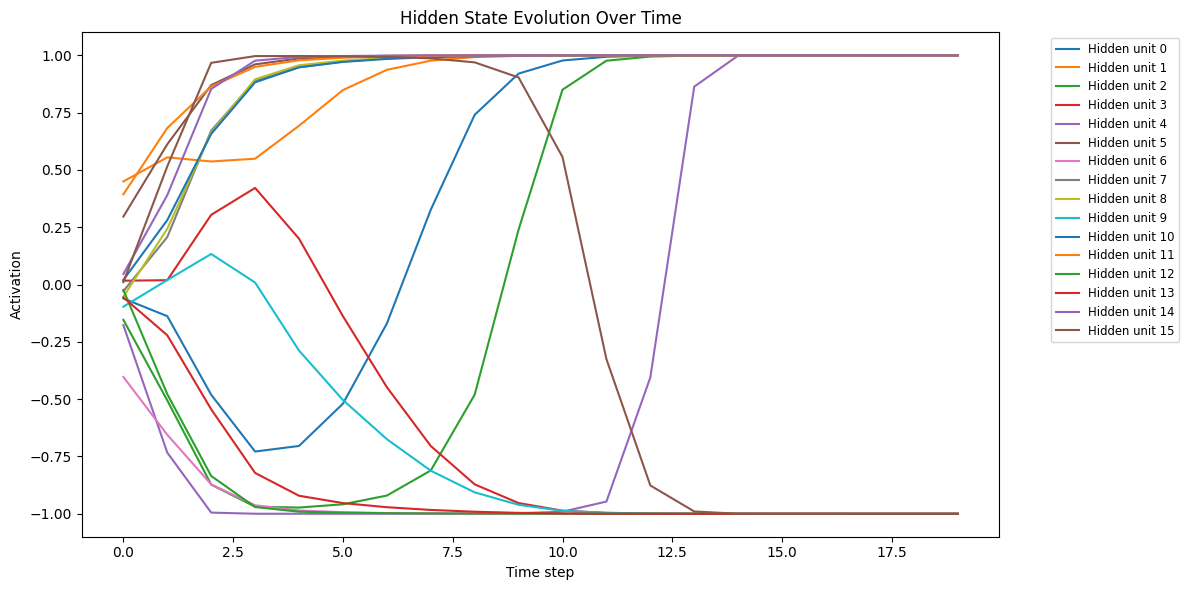

In [74]:
# Plot loss curve
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Test the model (after training)
with torch.no_grad():
    test_seq = generate_sequence()
    h = torch.zeros(batch_size, hidden_size)
    predictions = []
    hidden_states_test = []
    for t in range(seq_length):
        x_t = test_seq[t].unsqueeze(0)
        h = torch.tanh(x_t @ Wxh + h @ Whh + bh)
        y_t = h @ Why + by
        predictions.append(y_t.item())
        hidden_states_test.append(h.numpy())

    # Plot predictions vs. actual
    plt.figure(figsize=(6, 4))
    plt.plot(test_seq.squeeze().numpy(), label='Input sequence')
    plt.plot(predictions, label='Predicted next')
    plt.legend()
    plt.title('Sequence Prediction')
    plt.show()

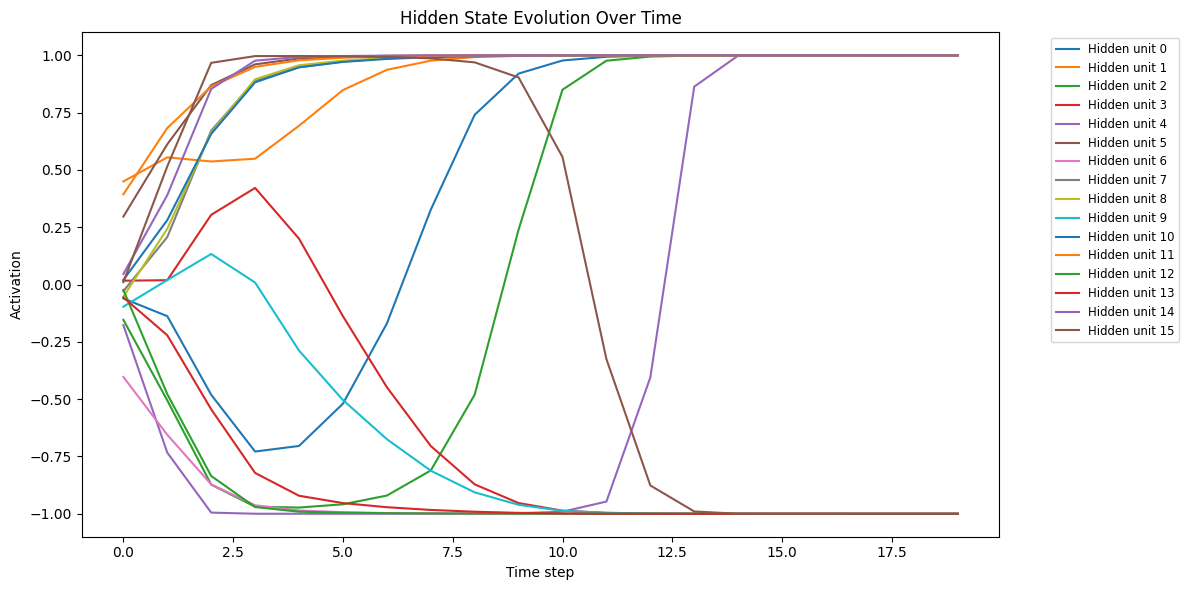

In [75]:
# Visualize hidden state evolution
hidden_states_test = torch.tensor(hidden_states_test).squeeze(1).numpy()  # shape: (seq_length, hidden_size)

plt.figure(figsize=(12, 6))
for i in range(hidden_size):
    plt.plot(hidden_states_test[:, i], label=f'Hidden unit {i}')
plt.title('Hidden State Evolution Over Time')
plt.xlabel('Time step')
plt.ylabel('Activation')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1, fontsize='small')
plt.tight_layout()
plt.show()